###Industrial machines generate large amounts of sensor data. Unexpected failures lead to downtime and maintenance costs. This project aims to predict machine failure before it occurs using machine sensor readings.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import joblib

#Dataset

##NASA C-MAPSS Turbofan Engine Dataset

###Features:

Engine ID
Operating cycle
Operational settings
21 sensor measurements

###Objective:

Predict whether the engine is approaching failure.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train_FD001.txt to train_FD001 (1).txt


In [ ]:
df = pd.read_csv(
    "train_FD001.txt",
    sep="\s+",
    header=None
)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_526/2051149536.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


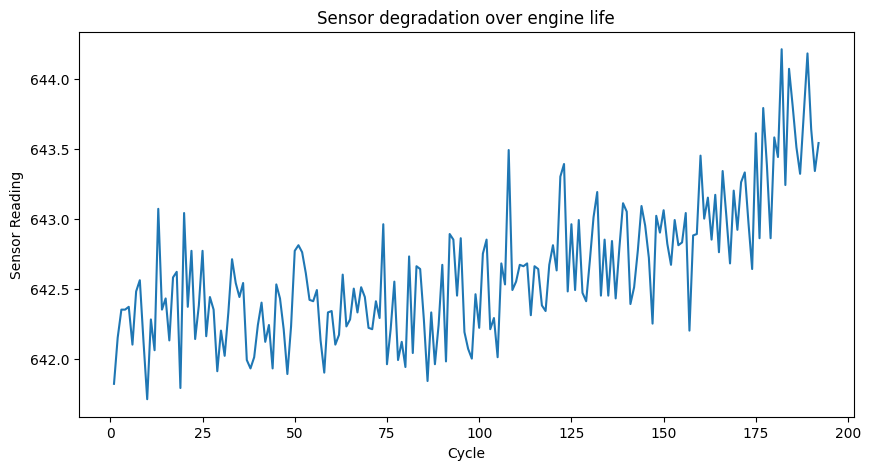

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
df[df[0]==1][1],
df[df[0]==1][6]
)

plt.xlabel("Cycle")
plt.ylabel("Sensor Reading")

plt.title(
"Sensor degradation over engine life"
)

plt.show()

In [ ]:
# Define column names

columns = [
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3"
]

# Add 21 sensor columns
for i in range(1,22):
    columns.append(f"sensor_{i}")


df.columns = columns

df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
# Find maximum cycle for each engine

max_cycle = df.groupby(
    "engine_id"
)["cycle"].max()


max_cycle.head()

,cycle
engine_id,
1,192
2,287
3,179
4,189
5,269


In [ ]:
df["max_cycle"] = df["engine_id"].map(max_cycle)

df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192


In [ ]:
df["RUL"] = (
    df["max_cycle"]
    -
    df["cycle"]
)

df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [ ]:
df["failure"] = np.where(
    df["RUL"] <= 30,
    1,
    0
)


df["failure"].value_counts()

,count
failure,
0,17531
1,3100


In [ ]:
X = df.drop(
    [
        "engine_id",
        "cycle",
        "max_cycle",
        "RUL",
        "failure"
    ],
    axis=1
)


y = df["failure"]

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [ ]:
rf_model.fit(
    X_train,
    y_train
)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
rf_prediction = rf_model.predict(
    X_test
)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy = accuracy_score(
    y_test,
    rf_prediction
)

print(
    "Accuracy:",
    accuracy
)

print(
classification_report(
    y_test,
    rf_prediction
)
)

Accuracy: 0.9631693724254907
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3507
           1       0.90      0.85      0.87       620

    accuracy                           0.96      4127
   macro avg       0.94      0.92      0.93      4127
weighted avg       0.96      0.96      0.96      4127



In [ ]:
!pip install xgboost
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [ ]:
xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_prediction = xgb_model.predict(
    X_test
)

In [ ]:
print(
accuracy_score(
    y_test,
    xgb_prediction
)
)

print(
classification_report(
    y_test,
    xgb_prediction
)
)

0.9634116791858492
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3507
           1       0.89      0.86      0.88       620

    accuracy                           0.96      4127
   macro avg       0.93      0.92      0.93      4127
weighted avg       0.96      0.96      0.96      4127



In [ ]:
results = pd.DataFrame(
{
    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,rf_prediction),
        accuracy_score(y_test,xgb_prediction)
    ]
})


results

,Model,Accuracy
0,Random Forest,0.963169
1,XGBoost,0.963412


In [ ]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
)


importance.sort_values(
    ascending=False
).head(10)

,0
sensor_11,0.585151
sensor_4,0.116876
sensor_9,0.064809
sensor_12,0.044090
sensor_7,0.028062
sensor_14,0.023876
sensor_15,0.019560
sensor_8,0.018240
sensor_17,0.018157
sensor_21,0.017530


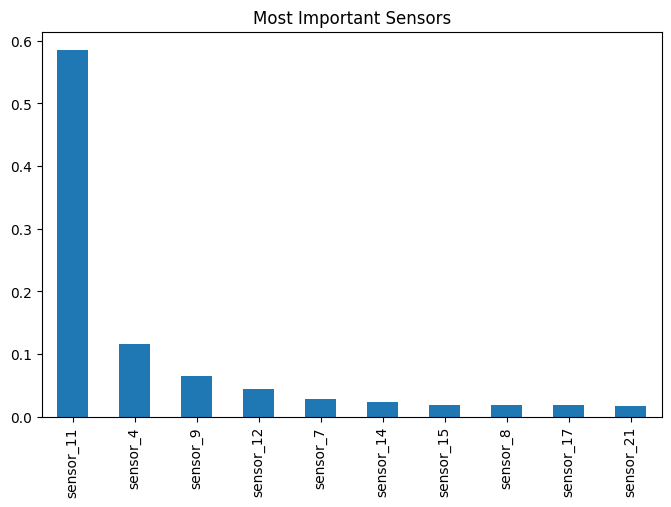

In [ ]:
plt.figure(figsize=(8,5))

importance.sort_values(
ascending=False
).head(10).plot(
kind="bar"
)

plt.title(
"Most Important Sensors"
)

plt.show()

In [ ]:
# Select one machine reading from test data

sample = X_test.iloc[[10]]

sample

,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
19494,-0.0033,-0.0001,100.0,518.67,642.63,1595.26,1413.93,14.62,21.61,553.31,...,520.79,2388.1,8158.08,8.4554,0.03,394,2388,100.0,38.81,23.3485


In [ ]:
prediction = xgb_model.predict(sample)

prediction

array([0])

In [ ]:
probability = xgb_model.predict_proba(sample)

probability

array([[0.9955302, 0.0044698]], dtype=float32)

In [ ]:
failure_probability = probability[0][1]


print(
    f"Failure Probability: {failure_probability*100:.2f}%"
)

Failure Probability: 0.45%


In [ ]:
failure_probability = probability[0][1]


if failure_probability < 0.3:
    status = "Healthy"

elif failure_probability < 0.7:
    status = "Warning"

else:
    status = "Critical"



print("Machine Health Report")
print("---------------------")

print(
    f"Failure Risk: {failure_probability*100:.2f}%"
)

print(
    f"Condition: {status}"
)

Machine Health Report
---------------------
Failure Risk: 0.45%
Condition: Healthy


In [ ]:
import joblib

In [ ]:
joblib.dump(
    xgb_model,
    "predictive_maintenance_model.pkl"
)

['predictive_maintenance_model.pkl']

In [ ]:
joblib.dump(
    X.columns.tolist(),
    "feature_names.pkl"
)

['feature_names.pkl']

In [ ]:
loaded_model = joblib.load(
    "predictive_maintenance_model.pkl"
)

In [ ]:
features = joblib.load(
    "feature_names.pkl"
)

In [ ]:
loaded_model.predict(sample)

array([0])

In [ ]:
def predict_machine_health(input_data):

    probability = xgb_model.predict_proba(
        input_data
    )[0][1]


    if probability < 0.3:
        status = "Healthy"

    elif probability < 0.7:
        status = "Warning"

    else:
        status = "Critical"


    return {
        "Failure Probability": round(probability*100,2),
        "Status": status
    }

In [ ]:
predict_machine_health(sample)

{'Failure Probability': np.float32(0.45), 'Status': 'Healthy'}

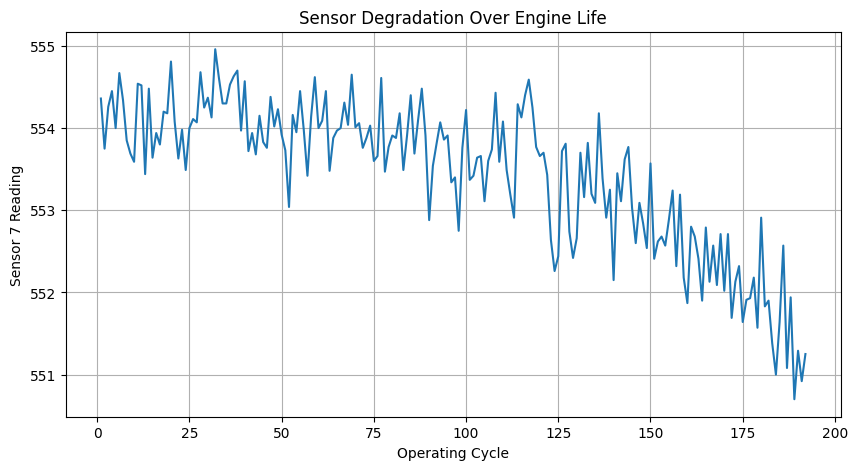

In [40]:
plt.figure(figsize=(10,5))

engine_1 = df[df["engine_id"] == 1]

plt.plot(
    engine_1["cycle"],
    engine_1["sensor_7"]
)

plt.xlabel("Operating Cycle")
plt.ylabel("Sensor 7 Reading")

plt.title(
    "Sensor Degradation Over Engine Life"
)

plt.grid()

plt.savefig(
    "sensor_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()